In [ ]:
#pip install pandas

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib

In [4]:
df = pd.read_csv("Obesity.csv")

df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [2]:
df.shape

(2111, 17)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(8), object(9)
memory u

In [6]:
df.isnull().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


In [7]:
df["Obesity"].value_counts()

,count
Obesity,
Obesity_Type_I,351
Obesity_Type_III,324
Obesity_Type_II,297
Overweight_Level_I,290
Overweight_Level_II,290
Normal_Weight,287
Insufficient_Weight,272


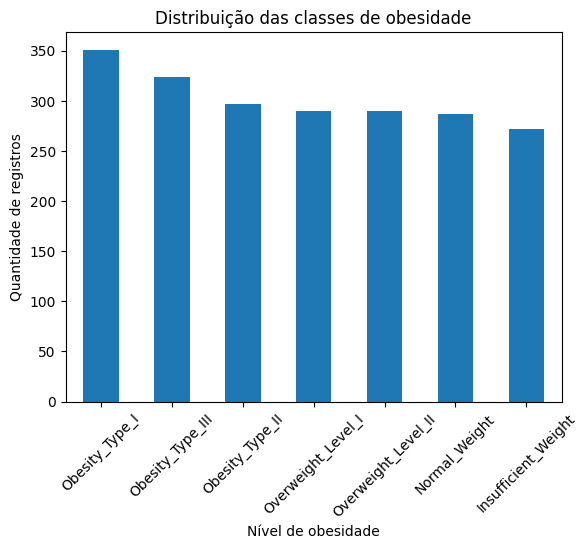

In [8]:
df["Obesity"].value_counts().plot(kind="bar")

plt.title("Distribuição das classes de obesidade")
plt.xlabel("Nível de obesidade")
plt.ylabel("Quantidade de registros")
plt.xticks(rotation=45)
plt.show()

In [9]:
X = df.drop(columns=["Obesity"])
y = df["Obesity"]

In [10]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

print("Colunas categóricas:")
print(categorical_cols)

print("\nColunas numéricas:")
print(numeric_cols)

Colunas categóricas:
Index(['Gender', 'family_history', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC',
       'MTRANS'],
      dtype='object')

Colunas numéricas:
Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'], dtype='object')


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [13]:
log_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

accuracy_log = accuracy_score(y_test, y_pred_log)

print("Acurácia Logistic Regression:", accuracy_log)

Acurácia Logistic Regression: 0.8747044917257684


In [14]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            random_state=42
        ))
    ]
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Acurácia Random Forest:", accuracy_rf)

Acurácia Random Forest: 0.9408983451536643


In [15]:
train_pred_rf = rf_model.predict(X_train)
test_pred_rf = rf_model.predict(X_test)

train_accuracy_rf = accuracy_score(y_train, train_pred_rf)
test_accuracy_rf = accuracy_score(y_test, test_pred_rf)

print("Acurácia treino:", train_accuracy_rf)
print("Acurácia teste:", test_accuracy_rf)
print("Diferença treino-teste:", train_accuracy_rf - test_accuracy_rf)

Acurácia treino: 1.0
Acurácia teste: 0.9408983451536643
Diferença treino-teste: 0.05910165484633567


In [16]:
rf_tuned_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42
        ))
    ]
)

rf_tuned_model.fit(X_train, y_train)

y_pred_rf_tuned = rf_tuned_model.predict(X_test)

accuracy_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)

print("Acurácia Random Forest ajustado:", accuracy_rf_tuned)

Acurácia Random Forest ajustado: 0.9078014184397163


In [17]:
train_pred_rf_tuned = rf_tuned_model.predict(X_train)
test_pred_rf_tuned = rf_tuned_model.predict(X_test)

train_accuracy_rf_tuned = accuracy_score(y_train, train_pred_rf_tuned)
test_accuracy_rf_tuned = accuracy_score(y_test, test_pred_rf_tuned)

print("Acurácia treino:", train_accuracy_rf_tuned)
print("Acurácia teste:", test_accuracy_rf_tuned)
print("Diferença treino-teste:", train_accuracy_rf_tuned - test_accuracy_rf_tuned)

Acurácia treino: 0.9739336492890995
Acurácia teste: 0.9078014184397163
Diferença treino-teste: 0.06613223084938324


In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    rf_tuned_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Scores da validação cruzada:", cv_scores)
print("Média:", cv_scores.mean())
print("Desvio padrão:", cv_scores.std())

Scores da validação cruzada: [0.93144208 0.8957346  0.92654028 0.90995261 0.92417062]
Média: 0.9175680369287307
Desvio padrão: 0.013048204691485493


In [19]:
print(classification_report(y_test, y_pred_rf_tuned))

                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.94      0.97        54
      Normal_Weight       0.75      0.90      0.82        58
     Obesity_Type_I       0.89      0.91      0.90        70
    Obesity_Type_II       0.95      0.98      0.97        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.89      0.81      0.85        58
Overweight_Level_II       0.90      0.81      0.85        58

           accuracy                           0.91       423
          macro avg       0.91      0.91      0.91       423
       weighted avg       0.91      0.91      0.91       423



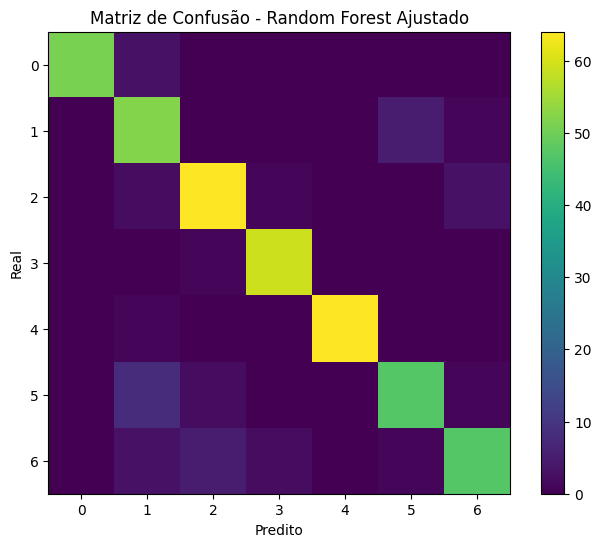

In [20]:
cm = confusion_matrix(y_test, y_pred_rf_tuned)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Matriz de Confusão - Random Forest Ajustado")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.colorbar()
plt.show()

In [21]:
import joblib

joblib.dump(rf_tuned_model, "modelo_obesidade.pkl")

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!


In [22]:
modelo_carregado = joblib.load("modelo_obesidade.pkl")

predicoes_teste = modelo_carregado.predict(X_test)

accuracy_loaded_model = accuracy_score(y_test, predicoes_teste)

print("Acurácia do modelo carregado:", accuracy_loaded_model)

Acurácia do modelo carregado: 0.9078014184397163


In [23]:
X_test.head(1)

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
572,Female,19.084967,1.768435,49.597765,no,yes,3.0,3.725797,Sometimes,no,1.191401,no,2.0,1.0,Sometimes,Public_Transportation


In [24]:
joblib.dump(list(X.columns), "colunas_modelo.pkl")

print("Colunas salvas com sucesso!")

Colunas salvas com sucesso!


In [25]:
df.to_csv("obesity_dashboard.csv", index=False)

print("Arquivo para dashboard salvo com sucesso!")

Arquivo para dashboard salvo com sucesso!
